# EEG Eye State Classification & Cognitive Monitoring
### Knowledge-Based Systems Project

1. **Preprocessing:** EDA, Outlier Detection (IQR), Correlation Analysis
2. **Feature extraction:** Rolling window statistics and Scaling
3. **Model Training:** 6 classifiers (LR, KNN, DT, RF, SVM, MLP)
4. **Cognitive Monitoring:** Blink Rate, Attention, and Fatigue metrics

In [100]:
# Setup and imports
import sys
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Scikit-learn imports
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay
)

%matplotlib inline 
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Create necessary directories
os.makedirs('plots', exist_ok=True)

# Constants for data processing
EEG_CHANNELS = [
    'AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2',
    'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4'
]
TARGET_COLUMN = 'eyeDetection'

print(f"EEG Channels: {len(EEG_CHANNELS)}")

EEG Channels: 14


## 1. Data Preprocessing
The preprocessing pipeline:
* **Data Loading:** Import and initial inspection
* **Outlier Detection:** Using the Interquartile Range (IQR) method
* **Correlation Analysis:** Analyzing relationships between EEG channels

In [101]:
# Data Preprocessing
def load_data(filepath='C:/Users/teoca/Desktop/school/SBC/project/data/EEG_Eye_State_Classification.csv'):
#load datase
    # Check path existence to prevent crash
    if not os.path.exists(filepath):
        print(f"ERROR: File not found at {filepath}")
        return None

    df = pd.read_csv(filepath)
    print("Data Loading: ")
    print(f"Dataset shape: {df.shape}")
    print(f"Number of samples: {df.shape[0]}")
    print(f"Number of features: {df.shape[1] - 1}")
    print(f"Target column: {TARGET_COLUMN}")
    print(f"\nColumn names: {df.columns.tolist()}")
    return df
# Load the dataset
data_path = "C:/Users/teoca/Desktop/school/SBC/project/data/EEG_Eye_State_Classification.csv"
df_raw = load_data(data_path)

Data Loading: 
Dataset shape: (14980, 15)
Number of samples: 14980
Number of features: 14
Target column: eyeDetection

Column names: ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4', 'eyeDetection']


In [102]:
def inspect_data(df):
    print("Data Inspection:")

    # Basic info
    print(f"First 5 rows:")
    print(df.head())
    
    # Missing values
    missing = df.isnull().sum()
    total_missing = missing.sum()
    print(f"\nMissing values per column:")
    print(missing)
    print(f"Total missing values: {total_missing}")
    
    # Duplicates
    n_duplicates = df.duplicated().sum()
    print(f"\nDuplicate rows: {n_duplicates}")
    
    # Statistical summary
    print(f"\nStatistical Summary:")
    print(df.describe())
    
    return {
        'missing_values': total_missing,
        'duplicates': n_duplicates,
        'stats': df.describe()
    }
if df_raw is not None:
    inspection_results = inspect_data(df_raw)

Data Inspection:
First 5 rows:
       AF3       F7       F3      FC5       T7       P7       O1       O2  \
0  4329.23  4009.23  4289.23  4148.21  4350.26  4586.15  4096.92  4641.03   
1  4324.62  4004.62  4293.85  4148.72  4342.05  4586.67  4097.44  4638.97   
2  4327.69  4006.67  4295.38  4156.41  4336.92  4583.59  4096.92  4630.26   
3  4328.72  4011.79  4296.41  4155.90  4343.59  4582.56  4097.44  4630.77   
4  4326.15  4011.79  4292.31  4151.28  4347.69  4586.67  4095.90  4627.69   

        P8       T8      FC6       F4       F8      AF4  eyeDetection  
0  4222.05  4238.46  4211.28  4280.51  4635.90  4393.85             0  
1  4210.77  4226.67  4207.69  4279.49  4632.82  4384.10             0  
2  4207.69  4222.05  4206.67  4282.05  4628.72  4389.23             0  
3  4217.44  4235.38  4210.77  4287.69  4632.31  4396.41             0  
4  4210.77  4244.10  4212.82  4288.21  4632.82  4398.46             0  

Missing values per column:
AF3             0
F7              0
F3        

In [103]:
def analyze_class_distribution(df):
#eye state distribution
    print("Class Distribution Analysis: ")
    
    class_counts = df[TARGET_COLUMN].value_counts()
    class_pct = df[TARGET_COLUMN].value_counts(normalize=True) * 100
    
    labels = {0: 'Eyes Open', 1: 'Eyes Closed'}
    
    for cls in class_counts.index:
        print(f"  {labels.get(cls, cls)}: {class_counts[cls]} samples "
              f"({class_pct[cls]:.1f}%)")
    
    # Class balance ratio
    ratio = class_counts.min() / class_counts.max()
    print(f"\nClass balance ratio: {ratio:.3f}")
    if ratio < 0.8:
        print("  Note: Classes are slightly imbalanced")
    else:
        print("  Classes are well-balanced")
    return class_counts

if df_raw is not None:
        class_dist = analyze_class_distribution(df_raw)

Class Distribution Analysis: 
  Eyes Open: 8257 samples (55.1%)
  Eyes Closed: 6723 samples (44.9%)

Class balance ratio: 0.814
  Classes are well-balanced


In [138]:
#remove outliers
def detect_outliers_iqr(df, columns=None, threshold=1.5):
    if columns is None:
        columns = EEG_CHANNELS
    print("Outlier Detection (IQR Method)")
    outlier_info = {}
    total_outliers = 0
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        n_outliers = len(outliers)
        total_outliers += n_outliers
        outlier_info[col] = {
            'count': n_outliers, 'percentage': n_outliers / len(df) * 100,
            'lower_bound': lower_bound, 'upper_bound': upper_bound
        }
        if n_outliers > 0:
            print(f"  {col}: {n_outliers} outliers ({n_outliers/len(df)*100:.2f}%)")
    print(f"\nTotal outlier instances across all channels: {total_outliers}")
    return outlier_info
outlier_info = detect_outliers_iqr(df_raw, EEG_CHANNELS)

Outlier Detection (IQR Method)
  AF3: 1485 outliers (9.91%)
  F7: 710 outliers (4.74%)
  F3: 825 outliers (5.51%)
  FC5: 601 outliers (4.01%)
  T7: 727 outliers (4.85%)
  P7: 1065 outliers (7.11%)
  O1: 348 outliers (2.32%)
  O2: 609 outliers (4.07%)
  P8: 584 outliers (3.90%)
  T8: 830 outliers (5.54%)
  FC6: 1063 outliers (7.10%)
  F4: 838 outliers (5.59%)
  F8: 1460 outliers (9.75%)
  AF4: 1592 outliers (10.63%)

Total outlier instances across all channels: 12737


In [139]:
#remove outliers
def remove_outliers_iqr(df, columns):
    print("remove outlier")
    original_size = len(df)
    df_clean = df.copy()
    
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    
    removed_count = original_size - len(df_clean)
    removed_pct = (removed_count / original_size) * 100
    
    print(f"  Original dataset size: {original_size}")
    print(f"  Cleaned dataset size: {len(df_clean)}")
    print(f"  Removed samples: {removed_count} ({removed_pct:.2f}%)")
    
    return df_clean
df_clean = remove_outliers_iqr(df_raw, EEG_CHANNELS)

remove outlier
  Original dataset size: 14980
  Cleaned dataset size: 10848
  Removed samples: 4132 (27.58%)


Class Distribution


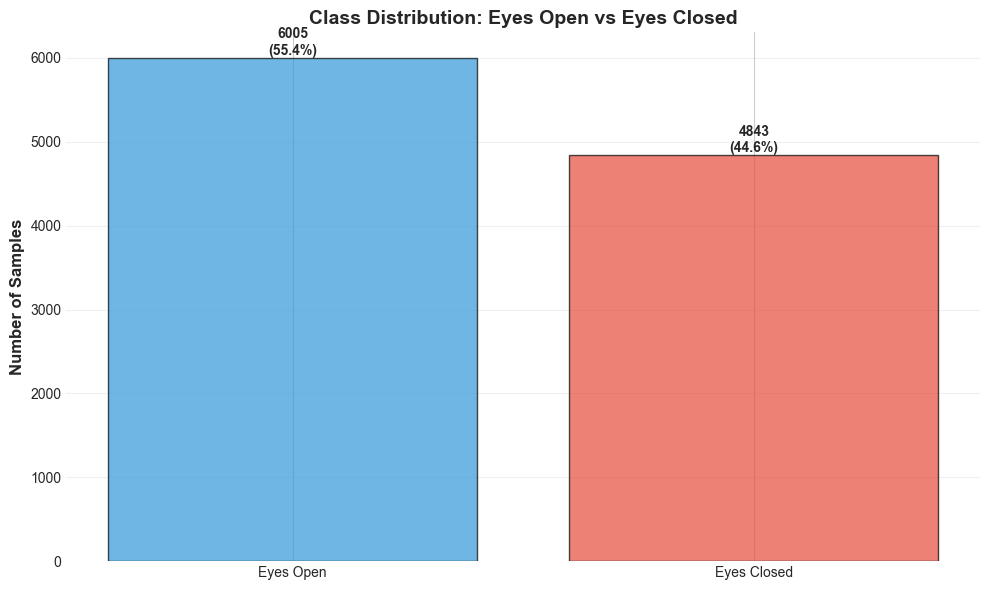

In [140]:
#visualise class distribution
# Plot 1: Class Distribution
print("Class Distribution")

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

class_counts = df_clean[TARGET_COLUMN].value_counts()
labels = ['Eyes Open', 'Eyes Closed']
colors = ['#3498db', '#e74c3c']

bars = ax.bar(labels, class_counts.values, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_title('Class Distribution: Eyes Open vs Eyes Closed', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(df_clean)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/00_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

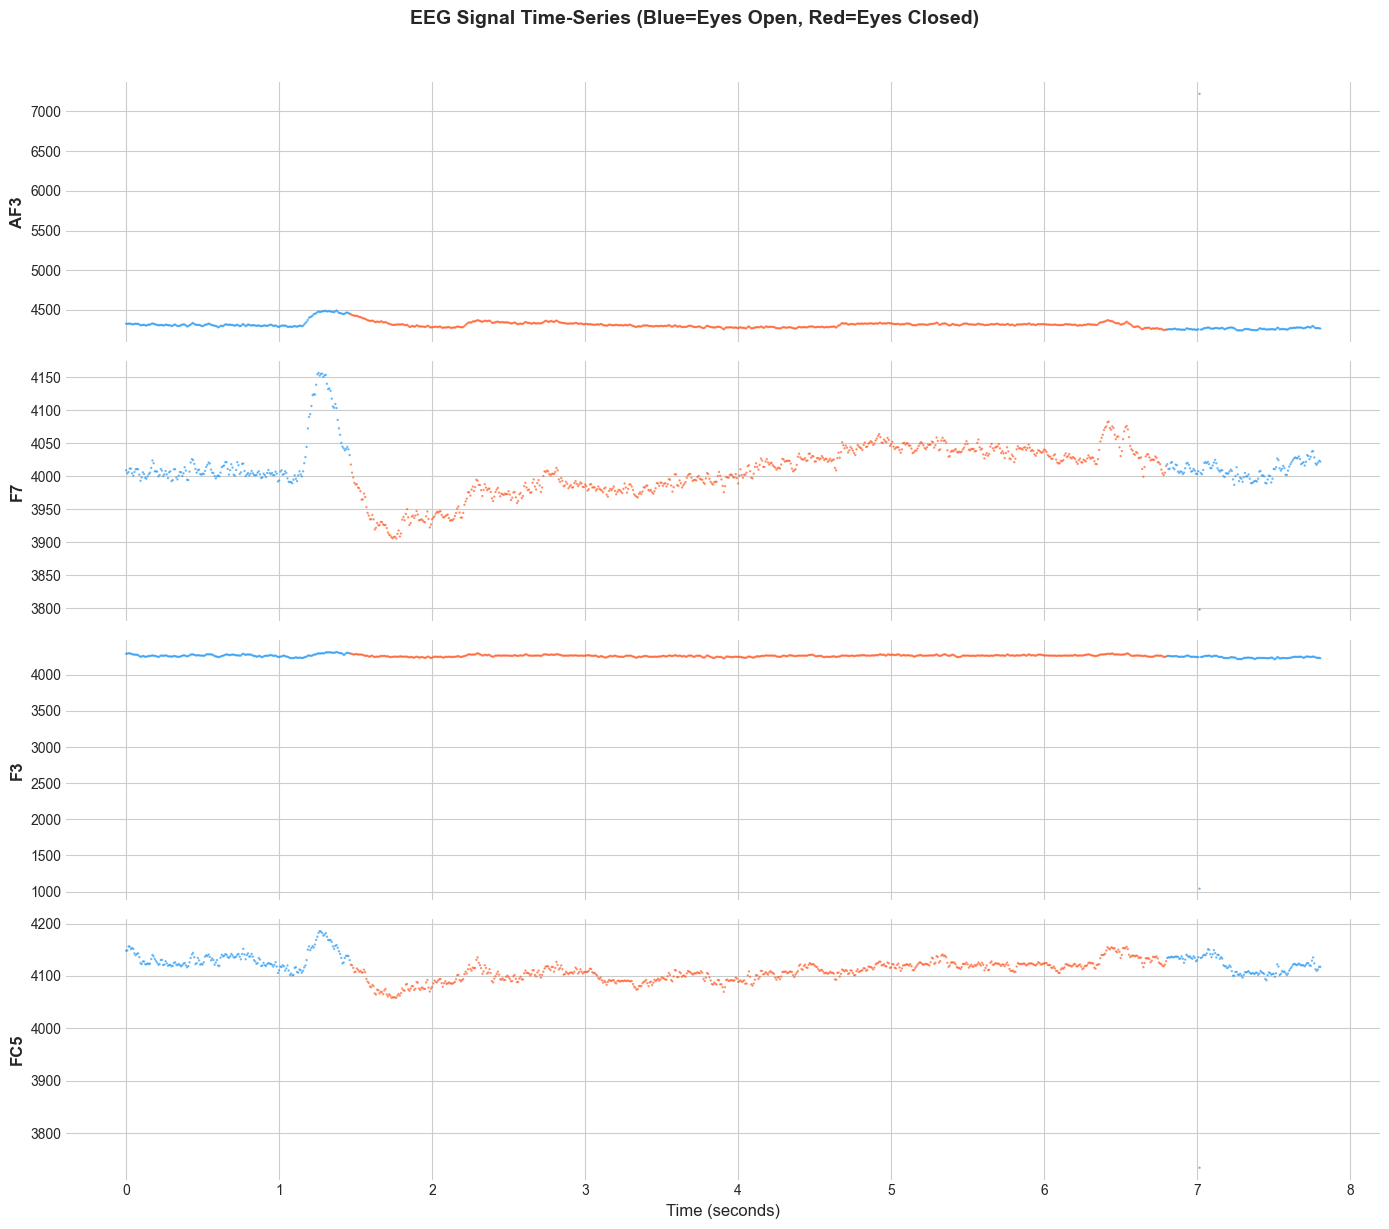

In [141]:
def plot_eeg_signals(df, n_samples=1000, channels=None):
    if channels is None:
        channels = EEG_CHANNELS[:4]
    fig, axes = plt.subplots(len(channels), 1, figsize=(14, 3 * len(channels)), sharex=True)
    time_axis = np.arange(n_samples) / 128
    for i, channel in enumerate(channels):
        ax = axes[i] if len(channels) > 1 else axes
        colors = ['#2196F3' if s == 0 else '#FF5722' for s in df[TARGET_COLUMN].values[:n_samples]]
        ax.scatter(time_axis, df[channel].values[:n_samples], c=colors, s=0.5, alpha=0.6)
        ax.set_ylabel(channel, fontsize=12, fontweight='bold')
        ax.tick_params(labelsize=10)
    axes[-1].set_xlabel('Time (seconds)', fontsize=12)
    fig.suptitle('EEG Signal Time-Series (Blue=Eyes Open, Red=Eyes Closed)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('plots/01_eeg_signals.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_eeg_signals(df_raw)

EEG Channel Distributions


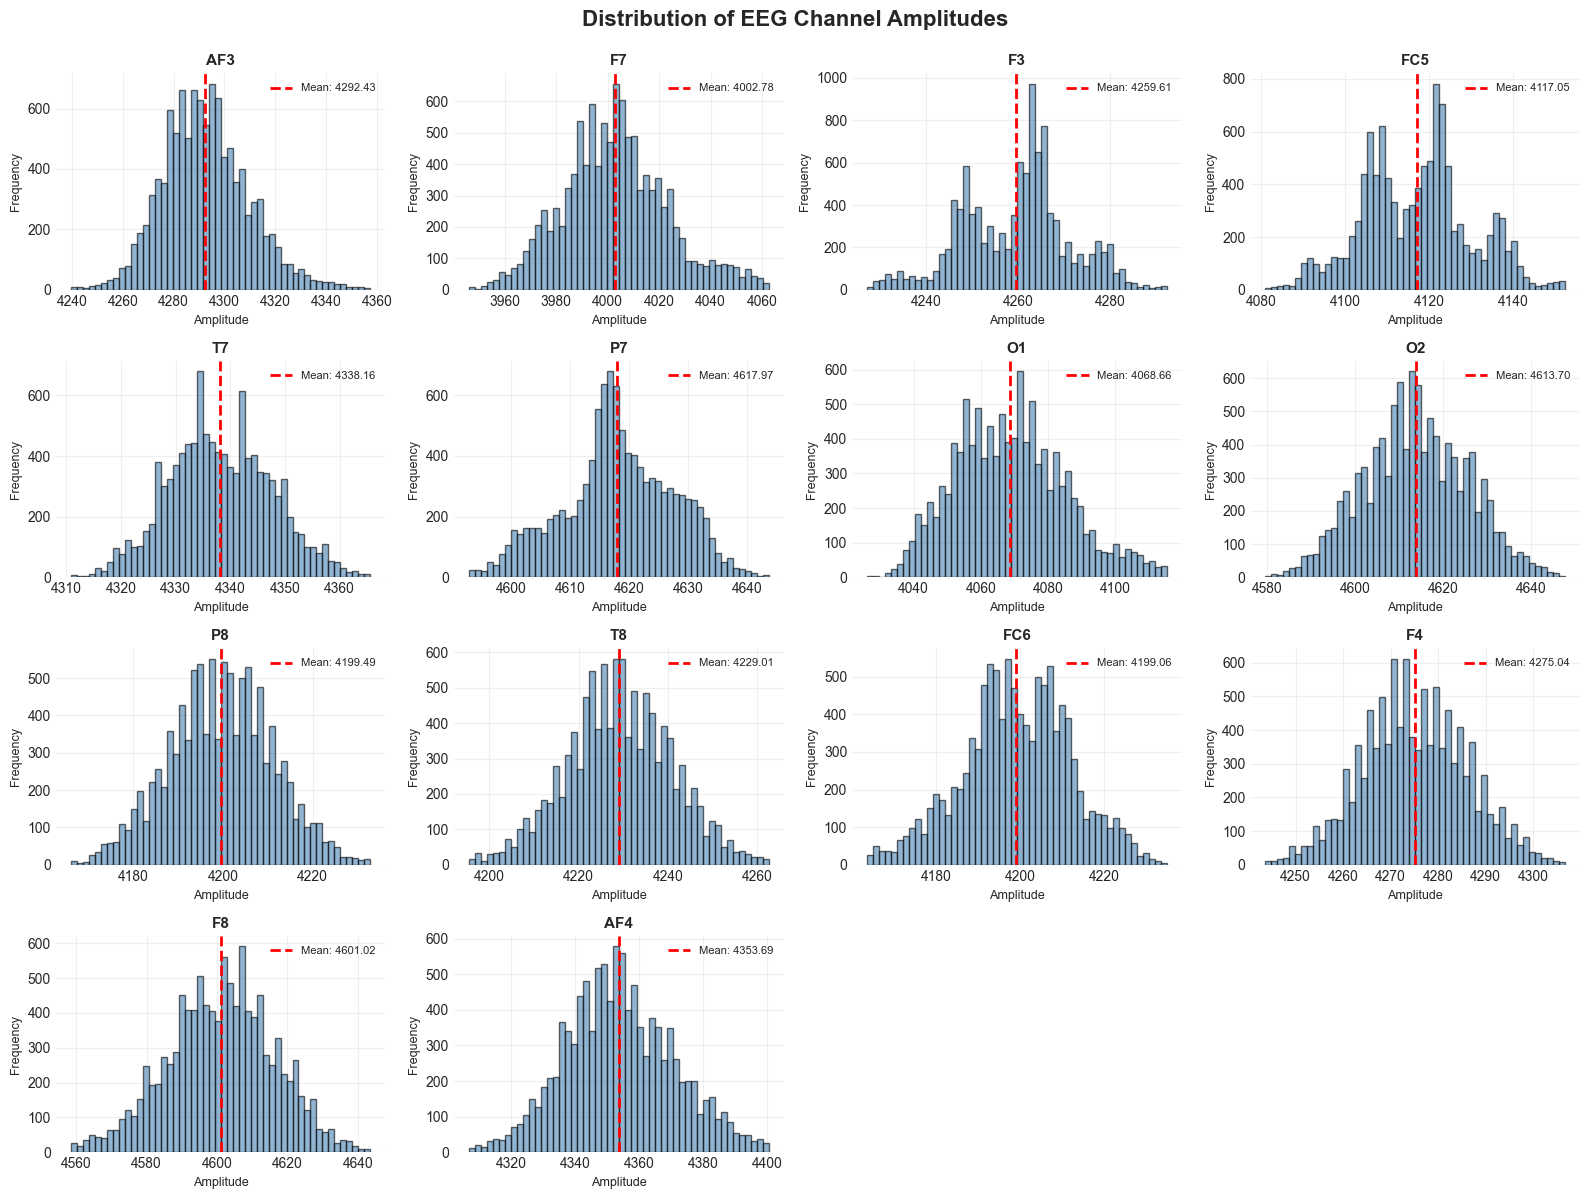

In [142]:
# Plot 2: EEG Channel Distributions
print("EEG Channel Distributions")

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, channel in enumerate(EEG_CHANNELS):
    ax = axes[idx]
    
    # Histogram with KDE
    ax.hist(df_clean[channel], bins=50, alpha=0.6, color='steelblue', edgecolor='black')
    ax.set_title(f'{channel}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Amplitude', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Add mean line
    mean_val = df_clean[channel].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax.legend(fontsize=8)

# Hide extra subplots if any
for idx in range(len(EEG_CHANNELS), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Distribution of EEG Channel Amplitudes', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('plots/02_channel_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

In [143]:
# Correlation Analysis
def analyze_correlation(df, channels):
    print("Correlation analysis")

    corr_matrix = df[channels].corr()
    
    # Find highly correlated pairs
    high_corr_pairs = []
    threshold = 0.8
    
    for i in range(len(channels)):
        for j in range(i+1, len(channels)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > threshold:
                high_corr_pairs.append((channels[i], channels[j], corr_val))
    
    print(f"\nHighly correlated channel pairs (|r| > {threshold}):")
    for ch1, ch2, corr in high_corr_pairs:
        print(f"  {ch1} <-> {ch2}: r = {corr:.3f}")
    
    print(f"\nTotal highly correlated pairs: {len(high_corr_pairs)}")
    
    return corr_matrix, high_corr_pairs
# Perform correlation analysis
corr_matrix, high_corr_pairs = analyze_correlation(df_clean, EEG_CHANNELS)

Correlation analysis

Highly correlated channel pairs (|r| > 0.8):
  AF3 <-> AF4: r = 0.838

Total highly correlated pairs: 1


Correlation Heatmap


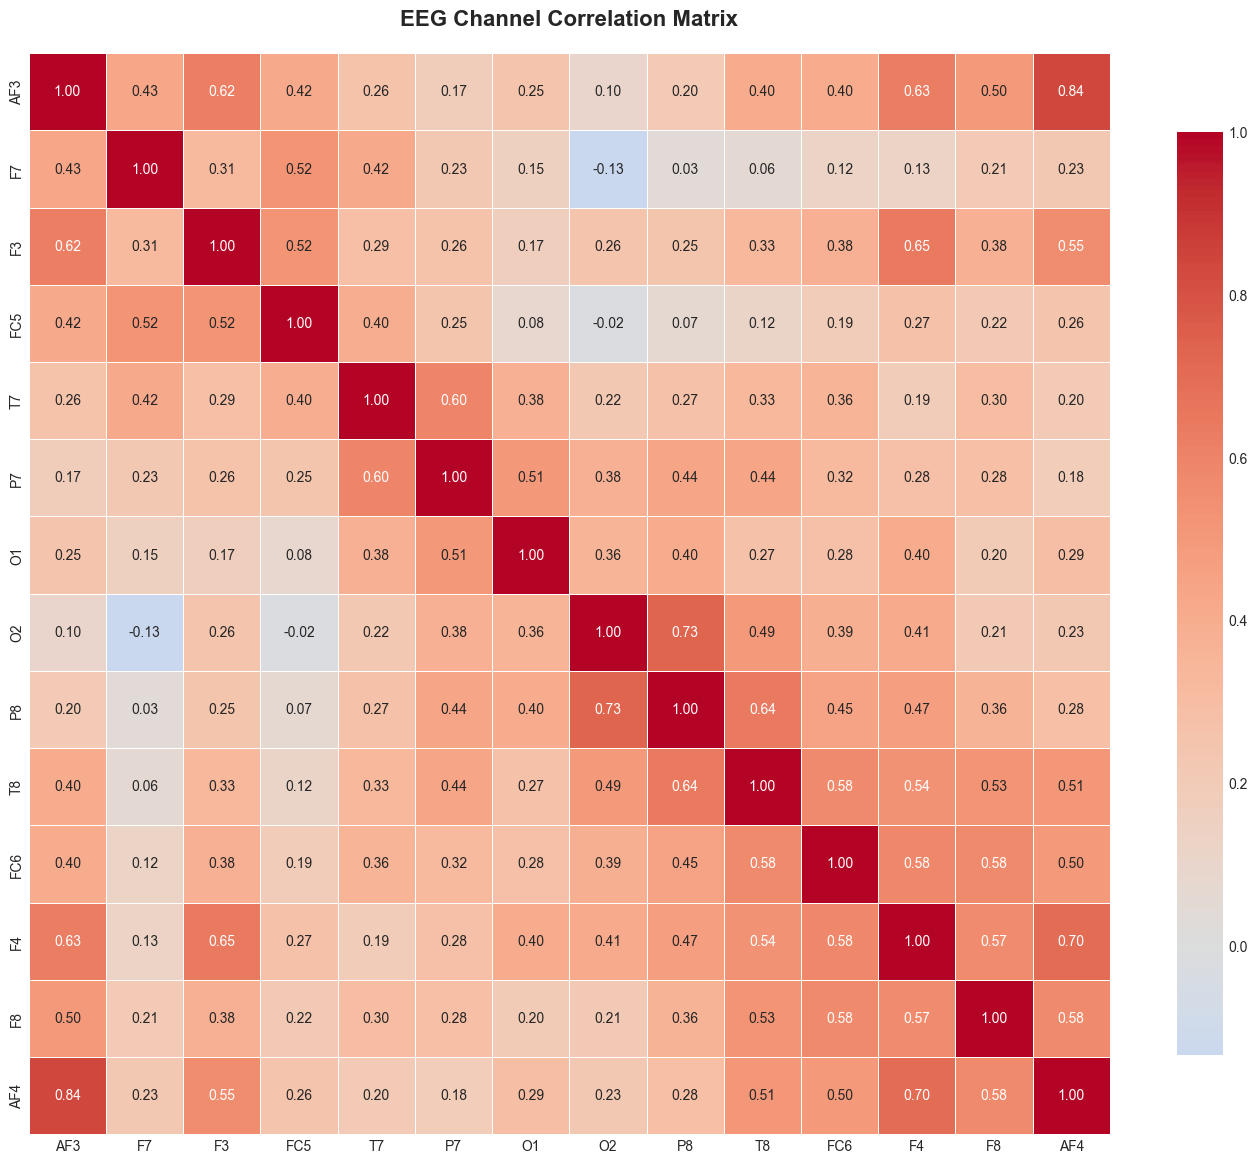

In [144]:
# Plot 3: Correlation Heatmap
print("Correlation Heatmap")

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, 
            cbar_kws={"shrink": 0.8}, ax=ax)

ax.set_title('EEG Channel Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('plots/03_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

Sample EEG Time Series


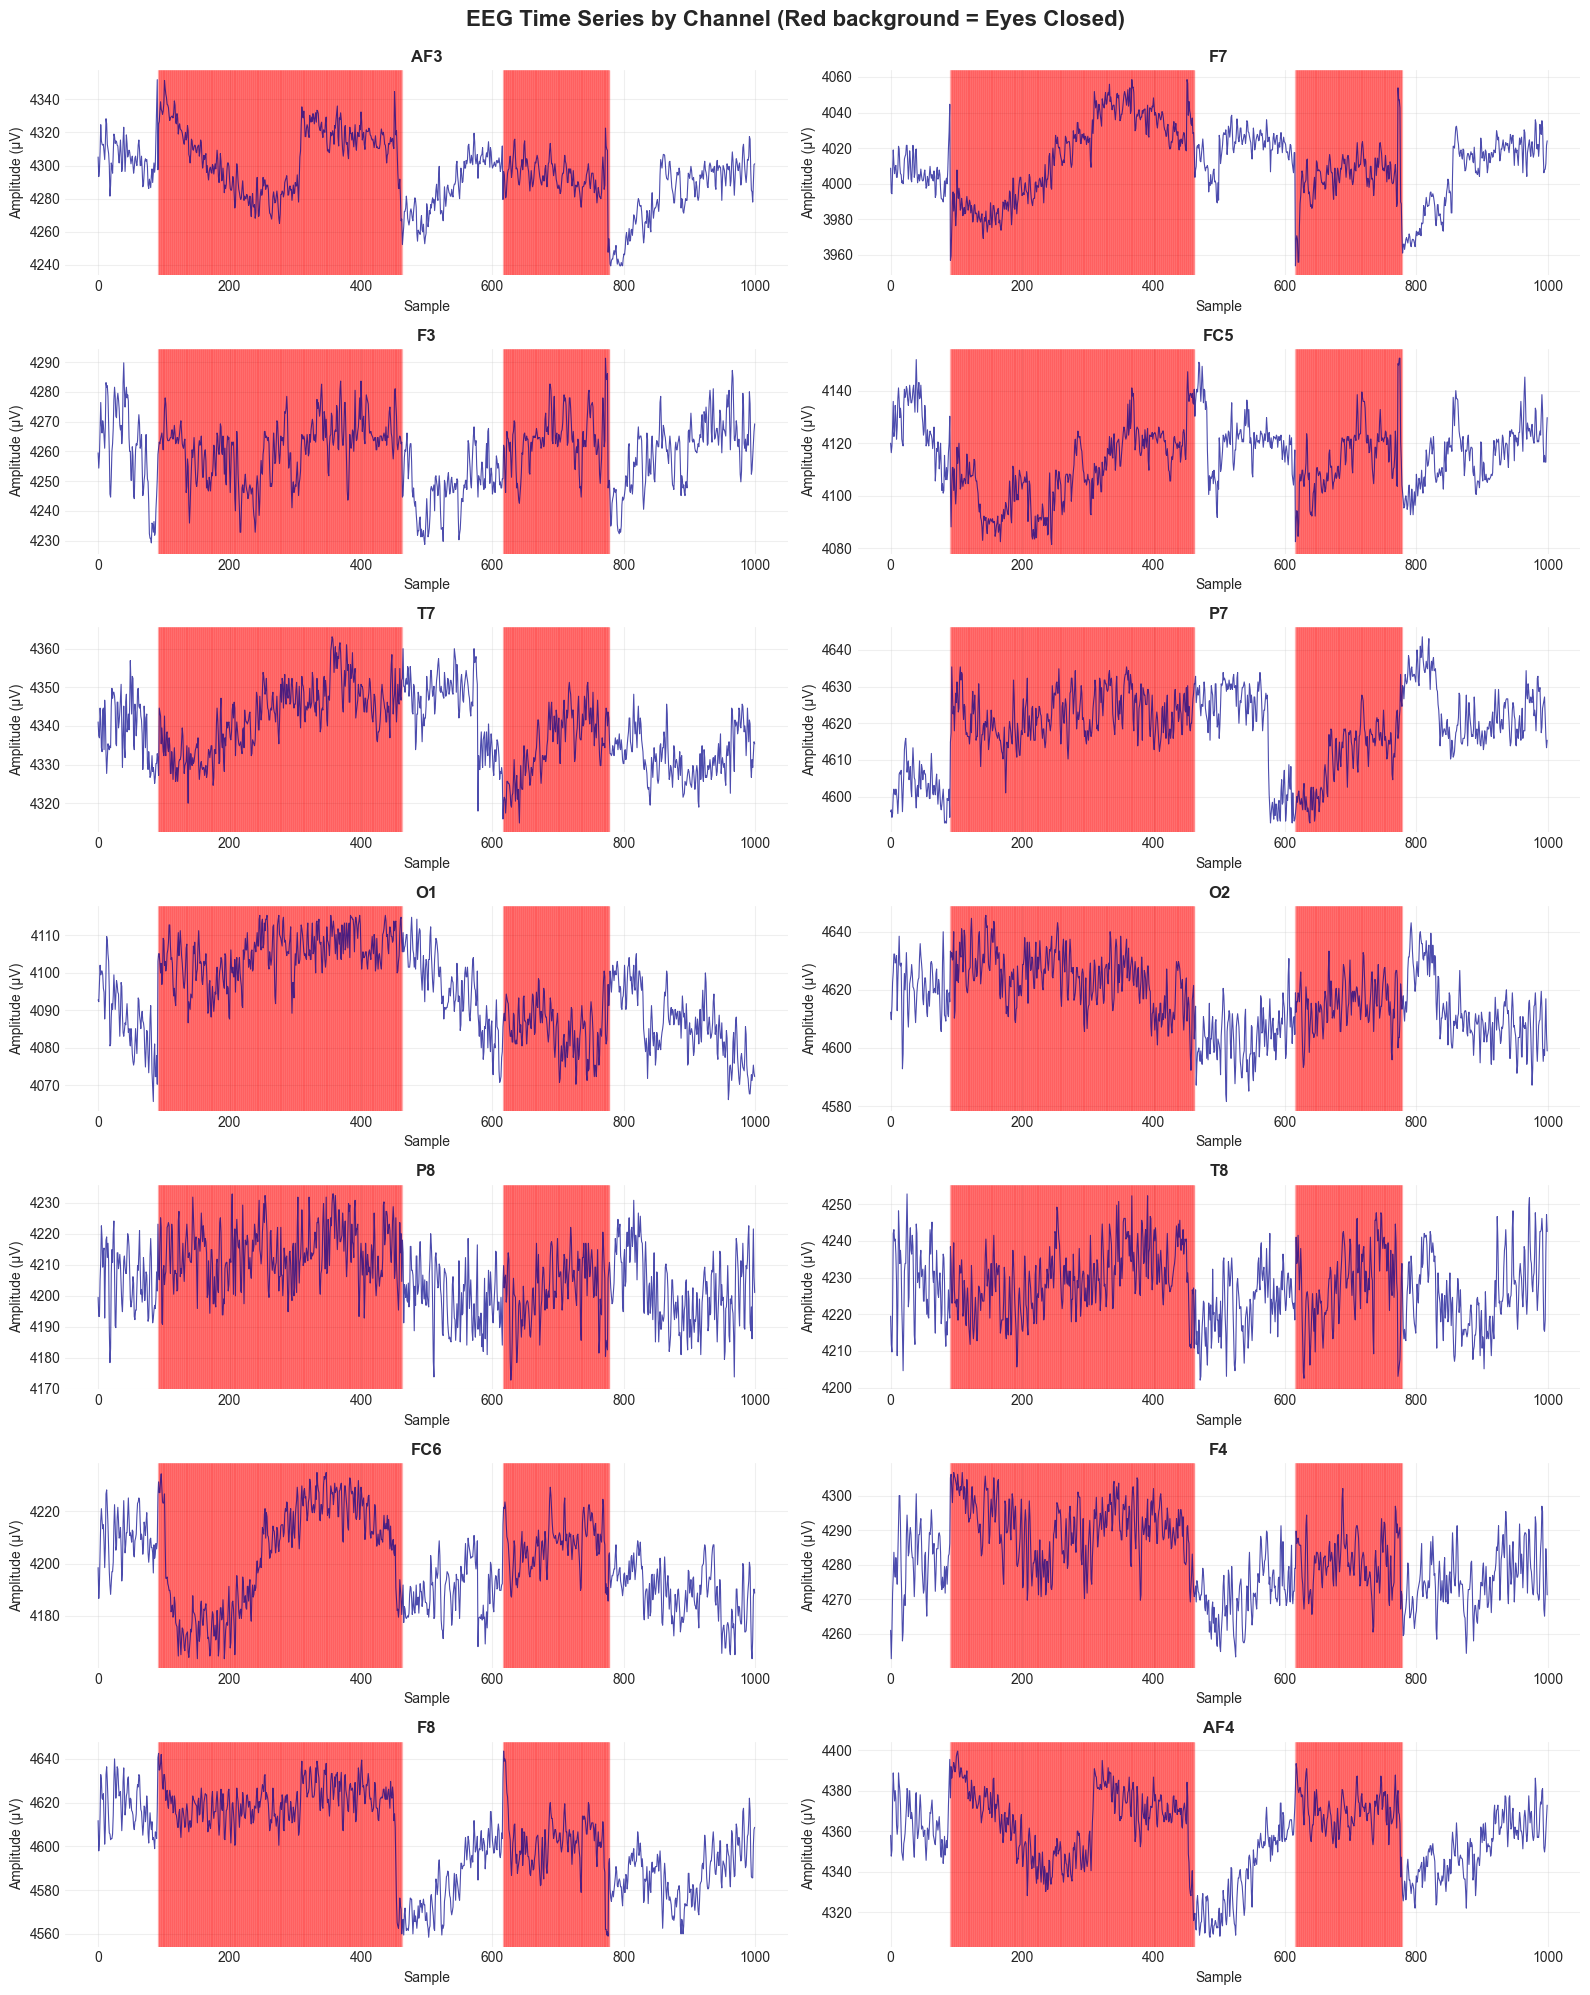

In [146]:
# Plot 4: Sample Time Series
print("Sample EEG Time Series")

# Select a representative sample (first 1000 points)
sample_size = 1000
df_sample = df_clean.head(sample_size)

fig, axes = plt.subplots(7, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, channel in enumerate(EEG_CHANNELS):
    ax = axes[idx]
    
    # Plot signal
    ax.plot(df_sample[channel].values, linewidth=0.8, color='darkblue', alpha=0.7)
    
    # Color background by eye state
    eye_states = df_sample[TARGET_COLUMN].values
    for i in range(len(eye_states)-1):
        if eye_states[i] == 1:  # Eyes closed
            ax.axvspan(i, i+1, alpha=0.2, color='red')
    
    ax.set_title(f'{channel}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Sample', fontsize=10)
    ax.set_ylabel('Amplitude (μV)', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('EEG Time Series by Channel (Red background = Eyes Closed)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('plots/04_time_series_sample.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Feature Extraction
Feature extraction pipeline:
* **Rolling Window Statistics:** Mean, std, min, max over windows
* **Feature Scaling:** StandardScaler normalization
* **Train-Test Split:** 80-20 split with stratification

In [147]:
# Feature Extraction

def add_rolling_features(df, channels, window_size=10):
    print("Feature extraction - Rolling Window Statistics: ")
    print(f"Window size: {window_size}")
    
    df_features = df.copy()
    new_features = []
    
    for channel in channels:
        # Rolling mean
        col_name = f'{channel}_roll_mean'
        df_features[col_name] = df[channel].rolling(window=window_size, min_periods=1).mean()
        new_features.append(col_name)
        
        # Rolling std
        col_name = f'{channel}_roll_std'
        df_features[col_name] = df[channel].rolling(window=window_size, min_periods=1).std()
        new_features.append(col_name)
        
        # Rolling min
        col_name = f'{channel}_roll_min'
        df_features[col_name] = df[channel].rolling(window=window_size, min_periods=1).min()
        new_features.append(col_name)
        
        # Rolling max
        col_name = f'{channel}_roll_max'
        df_features[col_name] = df[channel].rolling(window=window_size, min_periods=1).max()
        new_features.append(col_name)
    
    # Fill any NaN values
    df_features.fillna(method='bfill', inplace=True)
    
    print(f"Original features: {len(channels)}")
    print(f"New rolling features: {len(new_features)}")
    print(f"Total features: {len(channels) + len(new_features)}")
    
    return df_features, new_features

In [148]:
def prepare_features(df, use_rolling=True):
#training prepare
    if use_rolling:
        df_features, rolling_features = add_rolling_features(df, EEG_CHANNELS)
        feature_cols = EEG_CHANNELS + rolling_features
    else:
        df_features = df.copy()
        feature_cols = EEG_CHANNELS
    
    X = df_features[feature_cols].values
    y = df_features[TARGET_COLUMN].values
    
    print(f"Feature matrix shape: {X.shape}")
    print(f"Target vector shape: {y.shape}")
    
    return X, y, feature_cols
X, y, feature_names = prepare_features(df_clean, use_rolling=True)

Feature extraction - Rolling Window Statistics: 
Window size: 10
Original features: 14
New rolling features: 56
Total features: 70
Feature matrix shape: (10848, 70)
Target vector shape: (10848,)


In [149]:
def split_and_scale_data(X, y, test_size=0.2, random_state=42):
#data splitting and scaling
    print("Data splitting and scaling")
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")
    print(f"Test size: {test_size * 100}%")
    
    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"\nFeatures scaled using StandardScaler")
    
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler
X_train, X_test, y_train, y_test, scaler = split_and_scale_data(X, y)
print(f"  - X_train: {X_train.shape}")
print(f"  - X_test: {X_test.shape}")
print(f"  - y_train: {y_train.shape}")
print(f"  - y_test: {y_test.shape}")

Data splitting and scaling
Training set: 8678 samples
Test set: 2170 samples
Test size: 20.0%

Features scaled using StandardScaler
  - X_train: (8678, 70)
  - X_test: (2170, 70)
  - y_train: (8678,)
  - y_test: (2170,)


## 4. Model Training

Training 6 different classifiers:
1. **Logistic Regression** - Linear baseline
2. **K-Nearest Neighbors** - Instance-based learning
3. **Decision Tree** - Non-linear, interpretable
4. **Random Forest** - Ensemble method
5. **Support Vector Machine** - Kernel-based
6. **Multi-Layer Perceptron** - Neural network

In [150]:
#model training
def train_single_model(name, model, X_train, X_test, y_train, y_test):
    print(f"Training: {name}")
    # Train
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='binary')
    rec = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # ROC-AUC (if predict_proba available)
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
    except:
        y_proba = None
        fpr, tpr, roc_auc = None, None, None
    
    print(f"  Training time: {train_time:.3f}s")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    if roc_auc:
        print(f"  ROC-AUC:   {roc_auc:.4f}")
    
    results = {
        'model': model,
        'name': name,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'auc': roc_auc,
        'confusion_matrix': cm,
        'fpr': fpr,
        'tpr': tpr,
        'train_time': train_time
    }
    
    return results

In [151]:
def train_all_models(X_train, X_test, y_train, y_test):
    print("Model Training")
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
        'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
        'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42),
        'Multi-Layer Perceptron': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
    }
    
    all_results = {}
    
    for name, model in models.items():
        results = train_single_model(name, model, X_train, X_test, y_train, y_test)
        all_results[name] = results
    
    return all_results
    # Train all models
all_results = train_all_models(X_train, X_test, y_train, y_test)

Model Training
Training: Logistic Regression
  Training time: 0.135s
  Accuracy:  0.7332
  Precision: 0.7221
  Recall:    0.6543
  F1-Score:  0.6865
  ROC-AUC:   0.7994
Training: K-Nearest Neighbors
  Training time: 0.001s
  Accuracy:  0.9977
  Precision: 0.9979
  Recall:    0.9969
  F1-Score:  0.9974
  ROC-AUC:   0.9995
Training: Decision Tree
  Training time: 0.370s
  Accuracy:  0.9355
  Precision: 0.9414
  Recall:    0.9123
  F1-Score:  0.9266
  ROC-AUC:   0.9471
Training: Random Forest
  Training time: 2.929s
  Accuracy:  0.9774
  Precision: 0.9873
  Recall:    0.9618
  F1-Score:  0.9744
  ROC-AUC:   0.9978
Training: Support Vector Machine
  Training time: 6.877s
  Accuracy:  0.9894
  Precision: 0.9896
  Recall:    0.9866
  F1-Score:  0.9881
  ROC-AUC:   0.9995
Training: Multi-Layer Perceptron
  Training time: 2.177s
  Accuracy:  0.9968
  Precision: 0.9949
  Recall:    0.9979
  F1-Score:  0.9964
  ROC-AUC:   1.0000


In [152]:
def create_comparison_df(all_results):
    comparison_data = []
    
    for name, res in all_results.items():
        comparison_data.append({
            'Model': name,
            'Accuracy': res['accuracy'],
            'Precision': res['precision'],
            'Recall': res['recall'],
            'F1-Score': res['f1'],
            'AUC': res['auc'],
            'Train Time (s)': res['train_time']
        })
    
    df_comparison = pd.DataFrame(comparison_data)
    df_comparison = df_comparison.sort_values('F1-Score', ascending=False).reset_index(drop=True)
    
    print("Model Comparison: ")

    print(df_comparison.to_string(index=False))
    
    return df_comparison
# Create comparison dataframe
comparison_df = create_comparison_df(all_results)
# Identify best model
best_model_name = comparison_df.iloc[0]['Model']
print(f"\n Best Model: {best_model_name}")
print(f"F1-Score: {comparison_df.iloc[0]['F1-Score']:.4f}")

Model Comparison: 
                 Model  Accuracy  Precision   Recall  F1-Score      AUC  Train Time (s)
   K-Nearest Neighbors  0.997696   0.997934 0.996904  0.997419 0.999527        0.001176
Multi-Layer Perceptron  0.996774   0.994856 0.997936  0.996394 0.999951        2.176532
Support Vector Machine  0.989401   0.989648 0.986584  0.988114 0.999460        6.877138
         Random Forest  0.977419   0.987288 0.961816  0.974386 0.997814        2.928770
         Decision Tree  0.935484   0.941427 0.912281  0.926625 0.947103        0.369703
   Logistic Regression  0.733180   0.722096 0.654283  0.686519 0.799418        0.134663

 Best Model: K-Nearest Neighbors
F1-Score: 0.9974


Model Performance Comparison


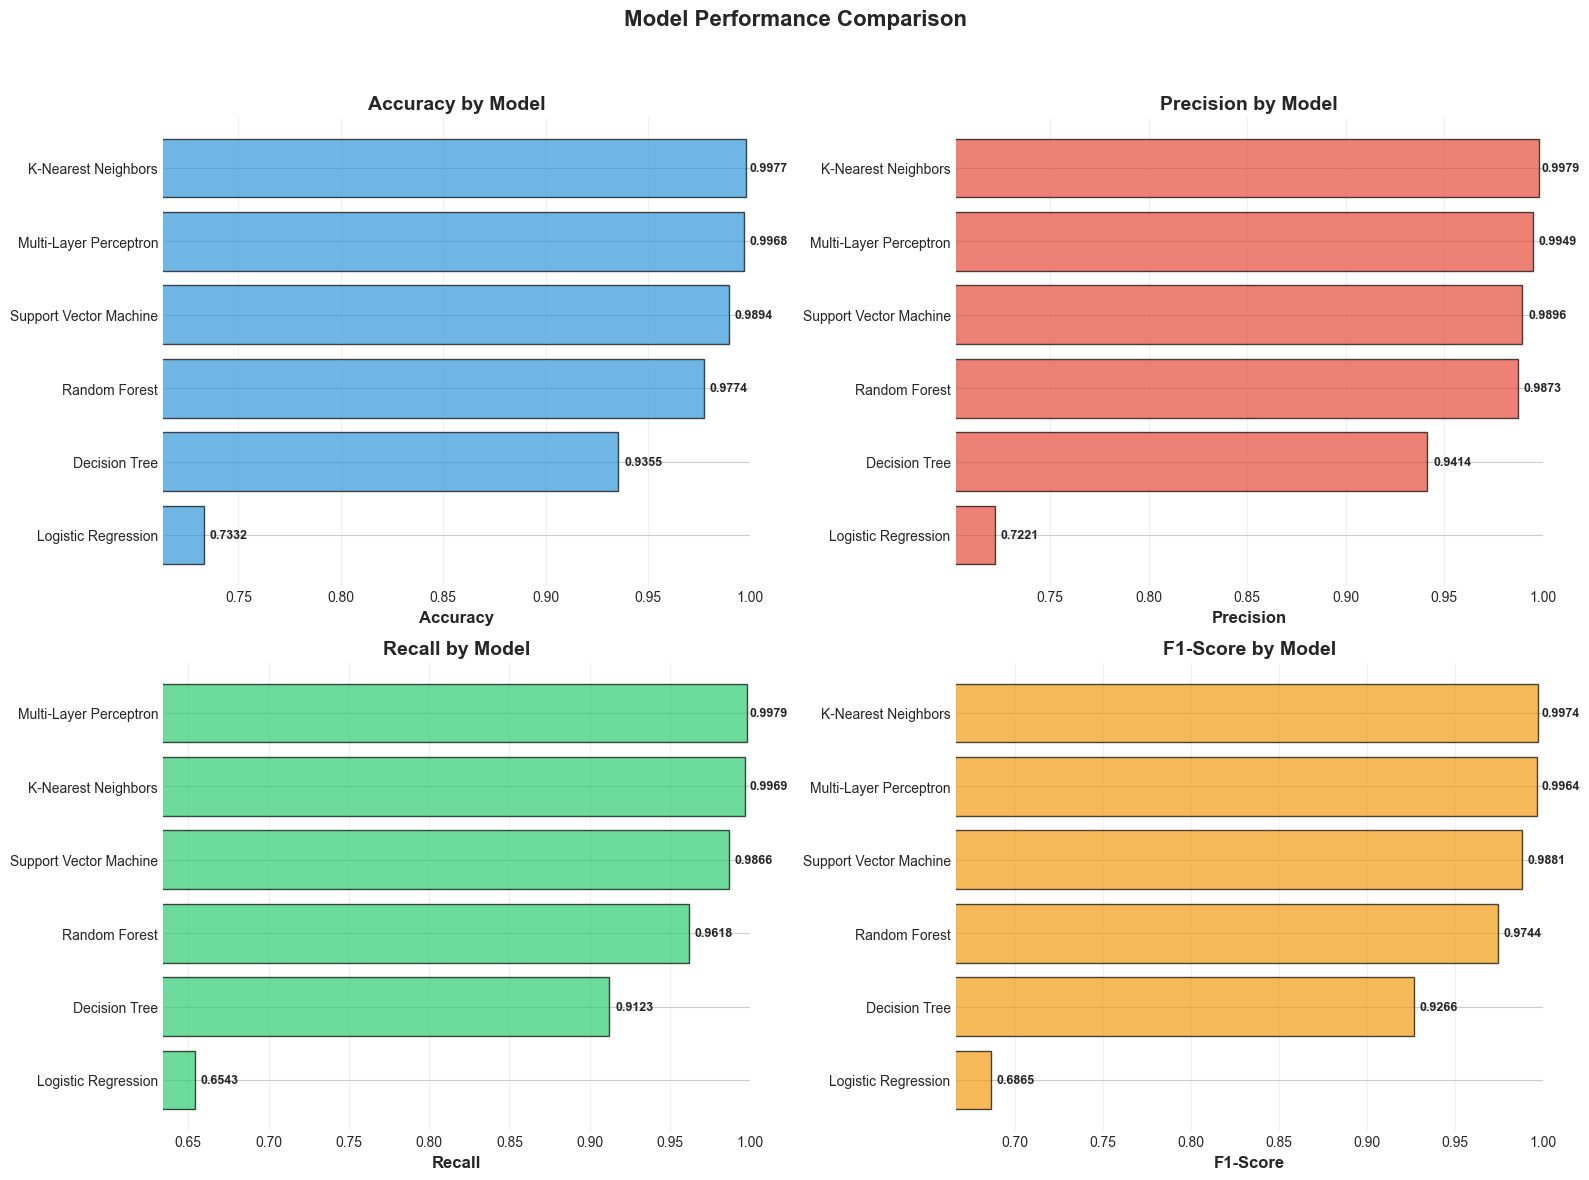

In [153]:
# Plot 5: Model Performance Comparison
import os
import numpy as np
import matplotlib.pyplot as plt

print("Model Performance Comparison")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]

    sorted_df = comparison_df.sort_values(metric, ascending=True)

    bars = ax.barh(
        sorted_df['Model'],
        sorted_df[metric],
        color=colors_palette[idx],
        alpha=0.7,
        edgecolor='black'
    )

    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} by Model', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    # Dynamic x-limits so bars don’t get clipped
    min_val = float(sorted_df[metric].min())
    max_val = float(sorted_df[metric].max())
    pad = 0.02
    left = max(0.0, min_val - pad)
    right = min(1.0, max_val + pad)
    if right - left < 0.1:  # avoid overly zoomed axis
        left = max(0.0, right - 0.1)
    ax.set_xlim(left, right)

    # Add value labels with small offset, keep them inside axis
    x_span = right - left
    offset = 0.01 * x_span

    for bar in bars:
        width = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2

        x_text = min(width + offset, right - 0.002 * x_span)
        ax.text(
            x_text, y, f'{width:.4f}',
            ha='left', va='center',
            fontweight='bold', fontsize=9
        )

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# Leave room for the suptitle
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Ensure folder exists before saving
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/05_model_comparison.png', dpi=300, bbox_inches='tight')

plt.show()

Confusion Matrices


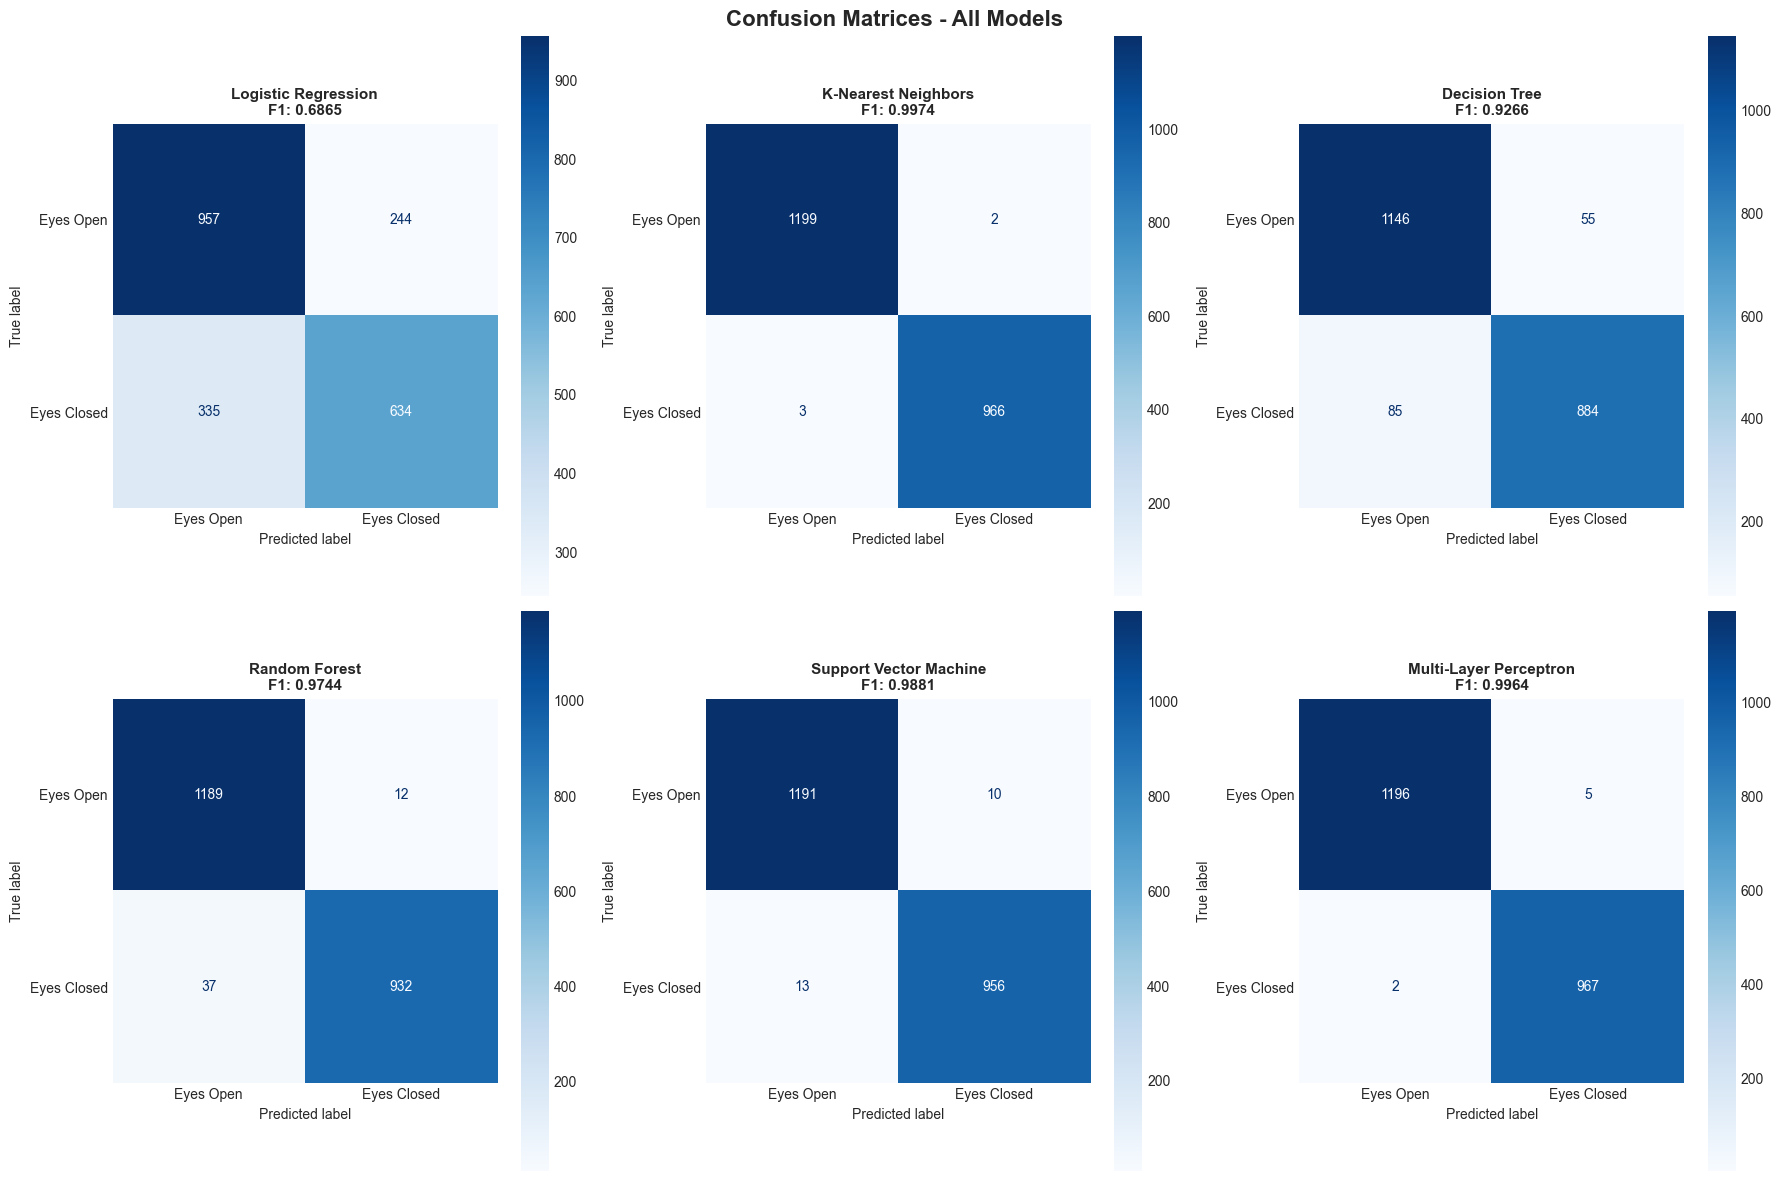

In [154]:
# Plot 6: Confusion Matrices for All Models
print("Confusion Matrices")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, results) in enumerate(all_results.items()):
    ax = axes[idx]
    
    cm = results['confusion_matrix']
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Eyes Open', 'Eyes Closed'])
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    
    ax.set_title(f'{name}\nF1: {results["f1"]:.4f}', fontweight='bold', fontsize=11)
    ax.grid(False)

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/06_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

ROC Curves


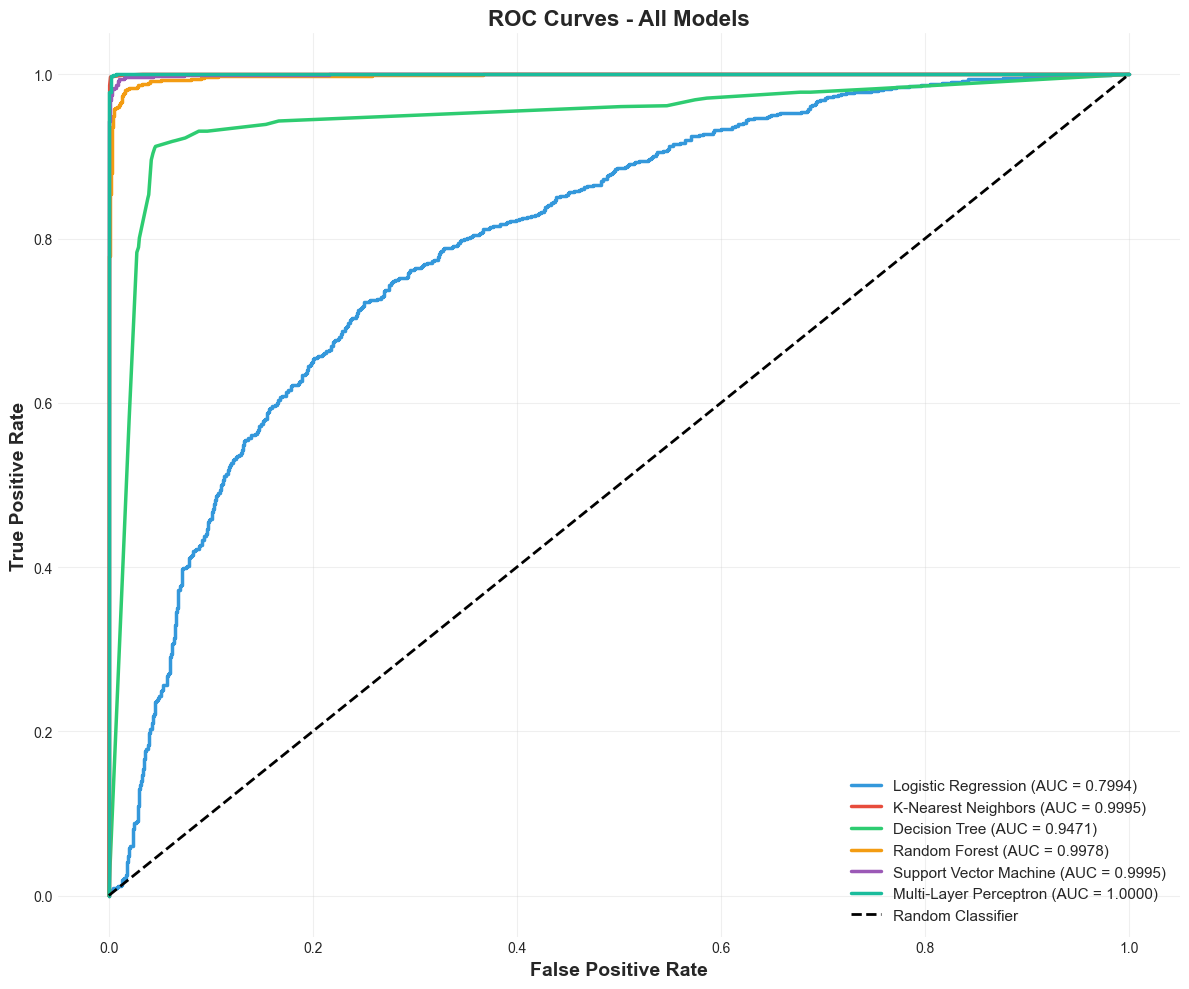

In [155]:
# Plot 7: ROC Curves
print("ROC Curves")

fig, ax = plt.subplots(figsize=(12, 10))

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for idx, (name, results) in enumerate(all_results.items()):
    if results['fpr'] is not None and results['tpr'] is not None:
        ax.plot(results['fpr'], results['tpr'], 
                label=f"{name} (AUC = {results['auc']:.4f})",
                linewidth=2.5, color=colors[idx])

# Diagonal line
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=14, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=14, fontweight='bold')
ax.set_title('ROC Curves - All Models', fontsize=16, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/07_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [156]:
# Feature Importance Analysis (for tree-based models)
print("Feature Importance Analysis")
# Get Random Forest feature importances
rf_model = all_results['Random Forest']['model']
feature_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features (Random Forest):")
print(feature_importances.head(10).to_string(index=False))

# Store for visualization
top_features = feature_importances.head(10)

Feature Importance Analysis

Top 10 Most Important Features (Random Forest):
      Feature  Importance
  P7_roll_min    0.049656
  O1_roll_max    0.045877
 O1_roll_mean    0.045085
 P7_roll_mean    0.044914
  O1_roll_min    0.041824
  P7_roll_max    0.039186
  F4_roll_max    0.025601
AF4_roll_mean    0.025356
           O1    0.025123
 F4_roll_mean    0.024645


Feature Importance


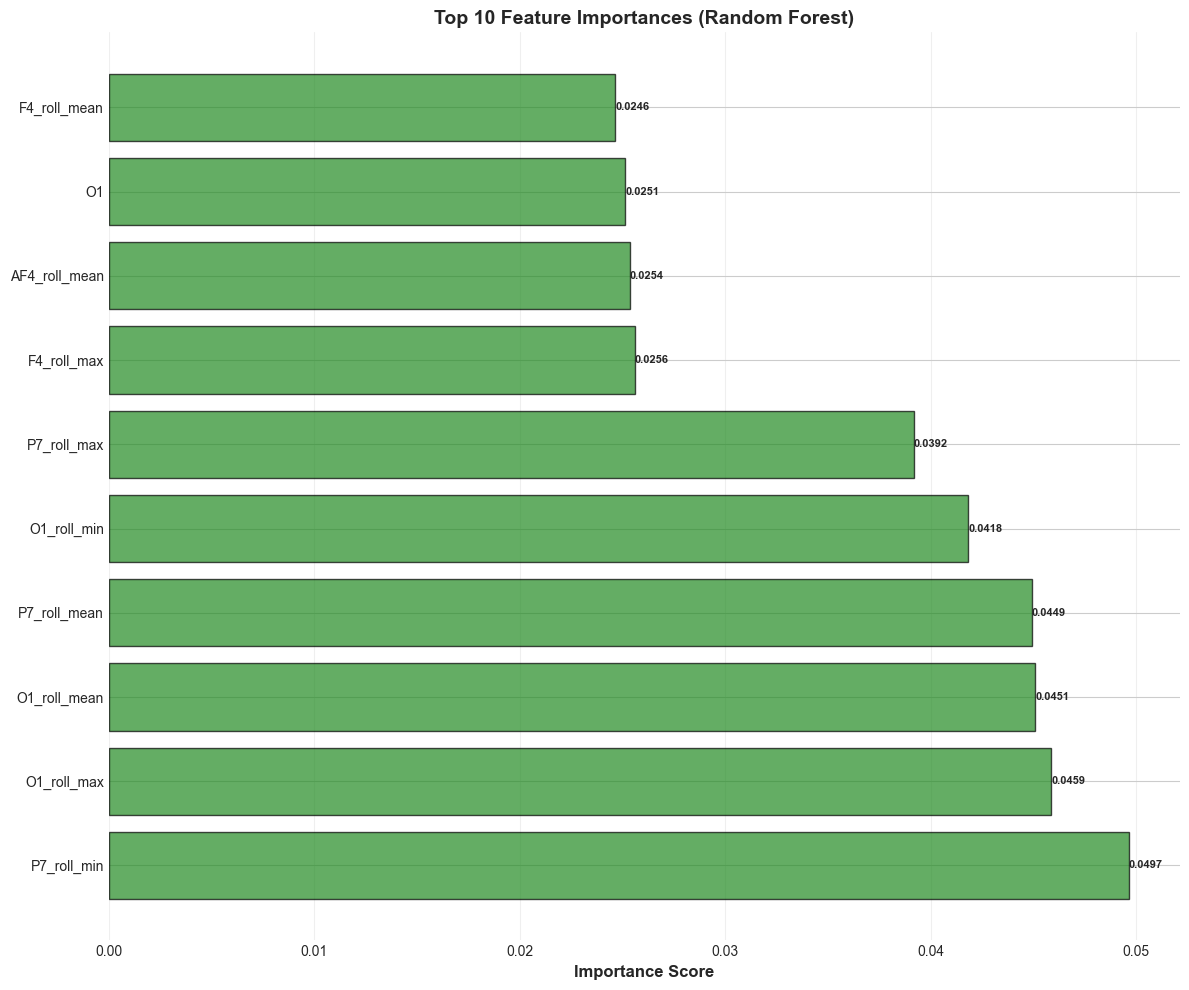

In [157]:
# Plot 8: Feature Importance
print("Feature Importance")

fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.barh(top_features['Feature'], top_features['Importance'], 
               color='forestgreen', alpha=0.7, edgecolor='black')

ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, f'{width:.4f}',
            ha='left', va='center', fontweight='bold', fontsize=8)

plt.tight_layout()
plt.savefig('plots/08_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Cognitive State Monitoring

Deriving cognitive metrics from eye state patterns:
* **Blink Detection:** Identifying eye closure events
* **Blink Rate:** Frequency of blinks per minute
* **Attention Score:** Based on blink patterns
* **Fatigue Index:** Detecting cognitive fatigue

In [158]:
# Cognitive Monitoring
def detect_blinks(eye_states, sampling_rate=128):
    print("Blink Detection")
    blinks = []
    in_blink = False
    blink_start = 0
    
    for i, state in enumerate(eye_states):
        if state == 1 and not in_blink:  # Blink starts
            in_blink = True
            blink_start = i
        elif state == 0 and in_blink:  # Blink ends
            in_blink = False
            blink_duration = (i - blink_start) / sampling_rate  # Duration in seconds
            blinks.append({
                'start': blink_start,
                'end': i,
                'duration': blink_duration
            })
    
    total_duration = len(eye_states) / sampling_rate / 60  # Total duration in minutes
    blink_rate_per_min = len(blinks) / total_duration if total_duration > 0 else 0
    
    avg_blink_duration = np.mean([b['duration'] for b in blinks]) if blinks else 0
    
    print(f"  Total blinks detected: {len(blinks)}")
    print(f"  Recording duration: {total_duration:.2f} minutes")
    print(f"  Blink rate: {blink_rate_per_min:.2f} blinks/minute")
    print(f"  Average blink duration: {avg_blink_duration:.4f} seconds")
    
    return {
        'blinks': blinks,
        'total_blinks': len(blinks),
        'blink_rate_per_min': blink_rate_per_min,
        'avg_duration': avg_blink_duration,
        'recording_duration_min': total_duration
    }

In [159]:
def calculate_attention_score(blink_rate):
    # Normalize: lower blink rate = higher attention
    # Assume optimal attention at 10 blinks/min, normal at 17
    if blink_rate < 10:
        attention = 100
    elif blink_rate < 17:
        attention = 100 - ((blink_rate - 10) / 7) * 30  # Scale from 100 to 70
    else:
        attention = 70 - min((blink_rate - 17) * 5, 70)  # Decrease further
    
    return max(0, min(100, attention))

In [160]:
def calculate_fatigue_index(eye_states, window_size=1000):
    print("Fatigue detection: ")
    fatigue_scores = []
    
    for i in range(0, len(eye_states), window_size):
        window = eye_states[i:i+window_size]
        # Fatigue = percentage of eyes closed in window
        closed_pct = (window == 1).sum() / len(window) * 100
        fatigue_scores.append(closed_pct)
    
    # Detect high fatigue periods (>40% eyes closed)
    fatigue_threshold = 40
    high_fatigue_periods = [i for i, score in enumerate(fatigue_scores) if score > fatigue_threshold]
    
    print(f"  Analysis window size: {window_size} samples")
    print(f"  Number of windows analyzed: {len(fatigue_scores)}")
    print(f"  Mean fatigue index: {np.mean(fatigue_scores):.2f}%")
    print(f"  Max fatigue index: {np.max(fatigue_scores):.2f}%")
    print(f"  High fatigue alerts: {len(high_fatigue_periods)} ({fatigue_threshold}% threshold)")
    
    return {
        'fatigue_scores': np.array(fatigue_scores),
        'mean_fatigue': np.mean(fatigue_scores),
        'max_fatigue': np.max(fatigue_scores),
        'alerts': high_fatigue_periods,
        'threshold': fatigue_threshold
    }

In [161]:
def cognitive_monitoring_pipeline(eye_states, sampling_rate=128):
    print("Cognitive monitoring")
    
    # Blink detection
    blink_data = detect_blinks(eye_states, sampling_rate)
    
    # Attention scores
    attention_scores = []
    window_size = 1000
    for i in range(0, len(eye_states), window_size):
        window = eye_states[i:i+window_size]
        window_blinks = detect_blinks(window, sampling_rate)
        attention = calculate_attention_score(window_blinks['blink_rate_per_min'])
        attention_scores.append(attention)
    
    attention_scores = np.array(attention_scores)
    
    print("Attention analysis")
    print(f"  Mean attention score: {np.mean(attention_scores):.2f}/100")
    print(f"  Min attention score: {np.min(attention_scores):.2f}/100")
    print(f"  Max attention score: {np.max(attention_scores):.2f}/100")
    
    # Fatigue detection
    fatigue_data = calculate_fatigue_index(eye_states, window_size=1000)
    
    return {
        'blink_data': blink_data,
        'attention_scores': attention_scores,
        'fatigue_indices': fatigue_data['fatigue_scores'],
        'alerts': fatigue_data['alerts']
    }

In [162]:
# Perform cognitive monitoring
eye_states = df_raw[TARGET_COLUMN].values
cognitive_results = cognitive_monitoring_pipeline(eye_states, sampling_rate=128)

Cognitive monitoring
Blink Detection
  Total blinks detected: 11
  Recording duration: 1.95 minutes
  Blink rate: 5.64 blinks/minute
  Average blink duration: 4.7599 seconds
Blink Detection
  Total blinks detected: 1
  Recording duration: 0.13 minutes
  Blink rate: 7.68 blinks/minute
  Average blink duration: 5.3359 seconds
Blink Detection
  Total blinks detected: 1
  Recording duration: 0.13 minutes
  Blink rate: 7.68 blinks/minute
  Average blink duration: 2.3594 seconds
Blink Detection
  Total blinks detected: 2
  Recording duration: 0.13 minutes
  Blink rate: 15.36 blinks/minute
  Average blink duration: 1.8906 seconds
Blink Detection
  Total blinks detected: 0
  Recording duration: 0.13 minutes
  Blink rate: 0.00 blinks/minute
  Average blink duration: 0.0000 seconds
Blink Detection
  Total blinks detected: 1
  Recording duration: 0.13 minutes
  Blink rate: 7.68 blinks/minute
  Average blink duration: 2.7500 seconds
Blink Detection
  Total blinks detected: 1
  Recording duration: 

Blink Pattern Analysis
Blink Detection
  Total blinks detected: 1
  Recording duration: 0.13 minutes
  Blink rate: 7.68 blinks/minute
  Average blink duration: 5.3359 seconds
Blink Detection
  Total blinks detected: 1
  Recording duration: 0.13 minutes
  Blink rate: 7.68 blinks/minute
  Average blink duration: 2.3594 seconds
Blink Detection
  Total blinks detected: 2
  Recording duration: 0.13 minutes
  Blink rate: 15.36 blinks/minute
  Average blink duration: 1.8906 seconds
Blink Detection
  Total blinks detected: 0
  Recording duration: 0.13 minutes
  Blink rate: 0.00 blinks/minute
  Average blink duration: 0.0000 seconds
Blink Detection
  Total blinks detected: 1
  Recording duration: 0.13 minutes
  Blink rate: 7.68 blinks/minute
  Average blink duration: 2.7500 seconds
Blink Detection
  Total blinks detected: 1
  Recording duration: 0.13 minutes
  Blink rate: 7.68 blinks/minute
  Average blink duration: 5.3438 seconds
Blink Detection
  Total blinks detected: 0
  Recording duration:

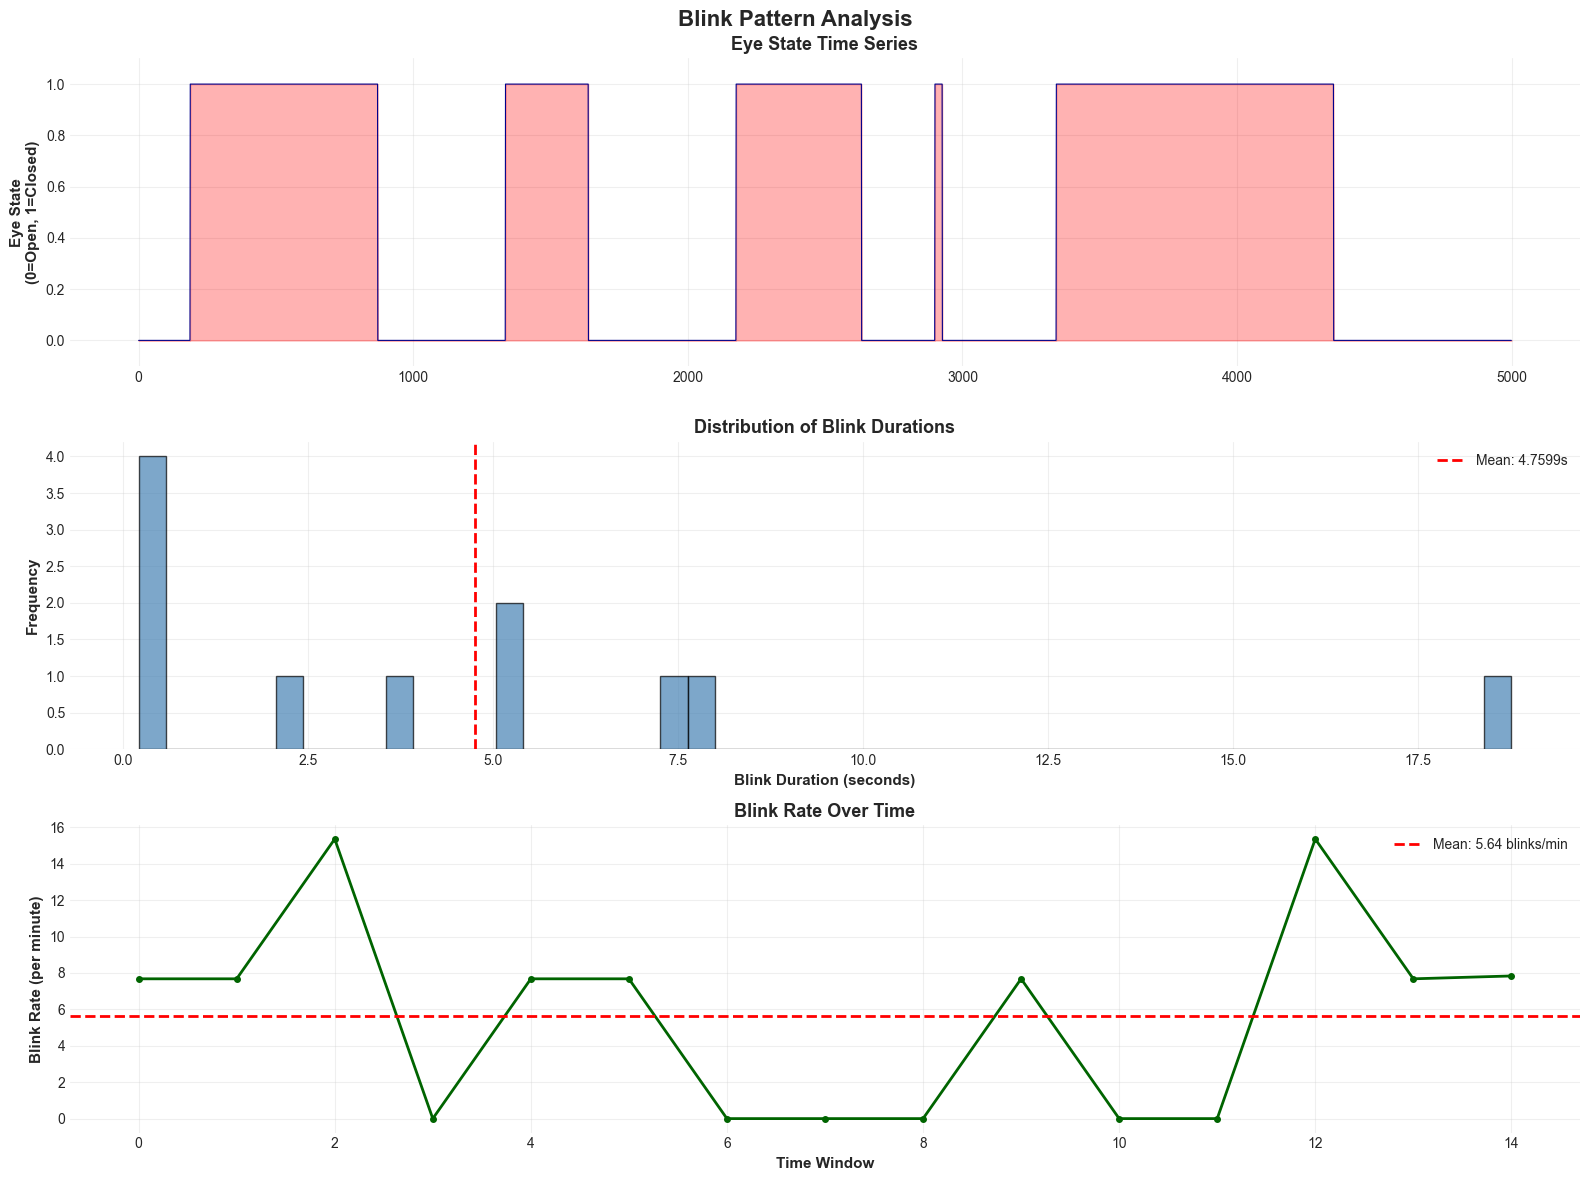

In [163]:
# Plot 9: Blink Pattern Analysis
print("Blink Pattern Analysis")

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Plot 1: Sample eye state sequence
sample_size = 5000
ax = axes[0]
ax.plot(eye_states[:sample_size], linewidth=0.8, color='darkblue')
ax.fill_between(range(sample_size), 0, eye_states[:sample_size], alpha=0.3, color='red')
ax.set_ylabel('Eye State\n(0=Open, 1=Closed)', fontsize=11, fontweight='bold')
ax.set_title('Eye State Time Series', fontsize=13, fontweight='bold')
ax.set_ylim([-0.1, 1.1])
ax.grid(True, alpha=0.3)

# Plot 2: Blink duration distribution
ax = axes[1]
blink_durations = [b['duration'] for b in cognitive_results['blink_data']['blinks']]
ax.hist(blink_durations, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(np.mean(blink_durations), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(blink_durations):.4f}s')
ax.set_xlabel('Blink Duration (seconds)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Distribution of Blink Durations', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 3: Blink rate over time
ax = axes[2]
window_size = 1000
blink_counts = []
for i in range(0, len(eye_states), window_size):
    window = eye_states[i:i+window_size]
    window_blinks = detect_blinks(window, 128)
    blink_counts.append(window_blinks['blink_rate_per_min'])

ax.plot(blink_counts, linewidth=2, color='darkgreen', marker='o', markersize=4)
ax.axhline(np.mean(blink_counts), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {np.mean(blink_counts):.2f} blinks/min')
ax.set_xlabel('Time Window', fontsize=11, fontweight='bold')
ax.set_ylabel('Blink Rate (per minute)', fontsize=11, fontweight='bold')
ax.set_title('Blink Rate Over Time', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Blink Pattern Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/09_blink_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

Attention and Fatigue Monitoring


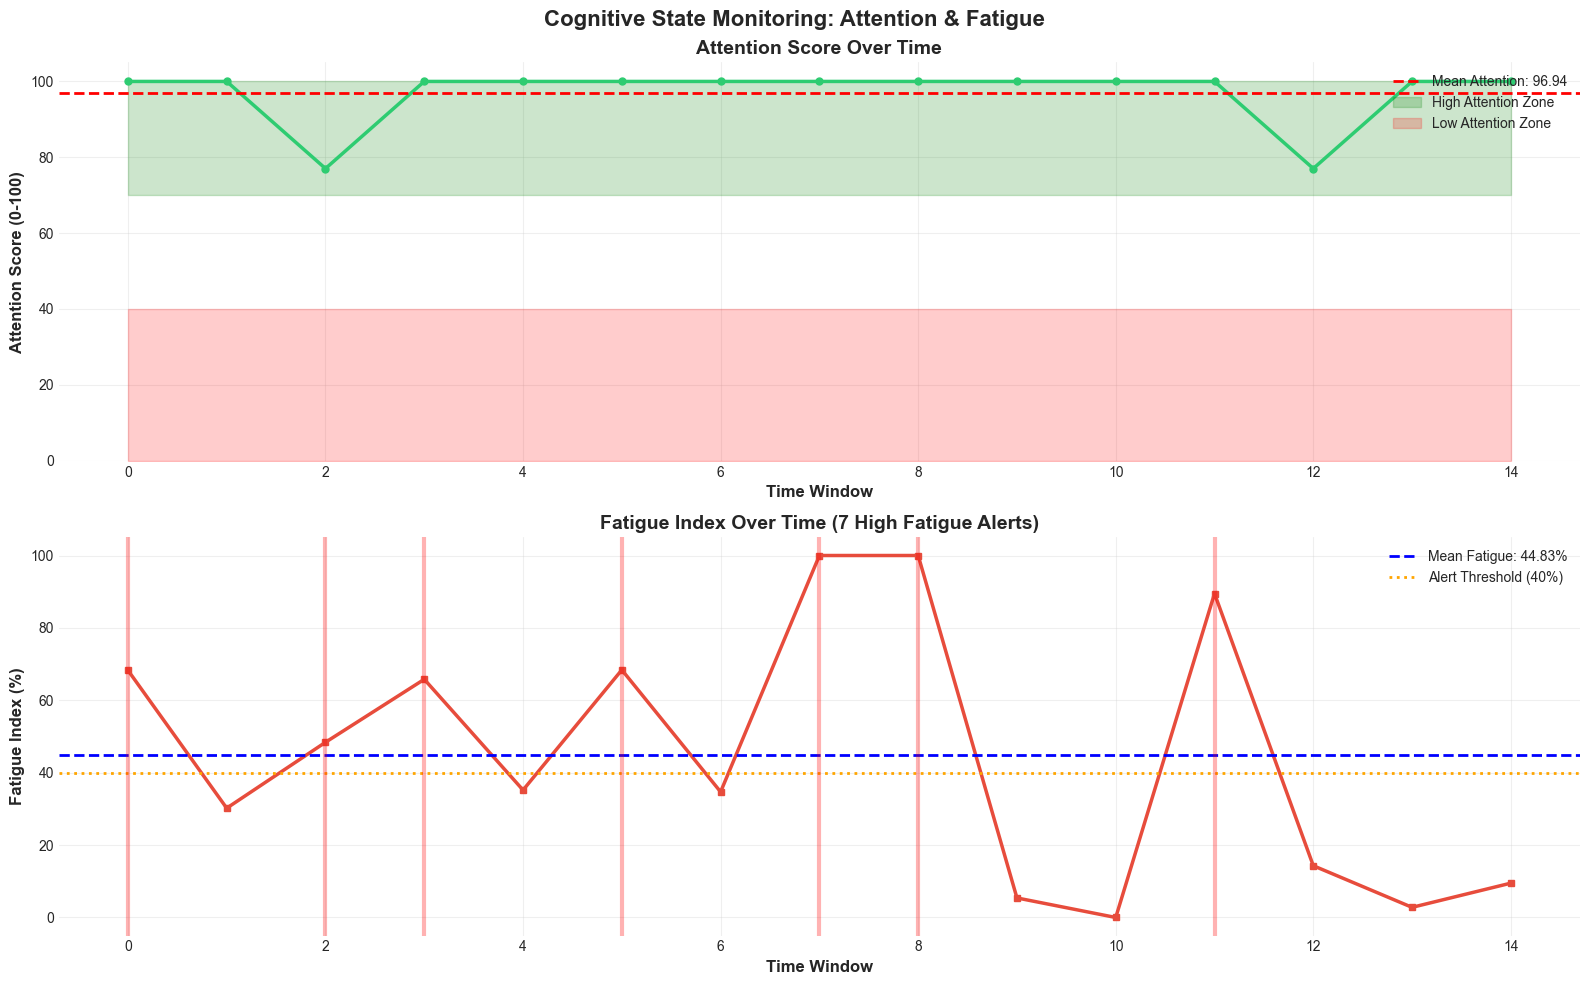

In [164]:
# Plot 10: Attention and Fatigue Monitoring
print("Attention and Fatigue Monitoring")

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Attention Score Over Time
ax = axes[0]
attention_scores = cognitive_results['attention_scores']
time_windows = range(len(attention_scores))

ax.plot(time_windows, attention_scores, linewidth=2.5, color='#2ecc71', marker='o', markersize=5)
ax.axhline(np.mean(attention_scores), color='red', linestyle='--', linewidth=2,
           label=f'Mean Attention: {np.mean(attention_scores):.2f}')
ax.fill_between(time_windows, 70, 100, alpha=0.2, color='green', label='High Attention Zone')
ax.fill_between(time_windows, 0, 40, alpha=0.2, color='red', label='Low Attention Zone')

ax.set_xlabel('Time Window', fontsize=12, fontweight='bold')
ax.set_ylabel('Attention Score (0-100)', fontsize=12, fontweight='bold')
ax.set_title('Attention Score Over Time', fontsize=14, fontweight='bold')
ax.set_ylim([0, 105])
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Fatigue Index Over Time
ax = axes[1]
fatigue_indices = cognitive_results['fatigue_indices']
fatigue_windows = range(len(fatigue_indices))
alerts = cognitive_results['alerts']

ax.plot(fatigue_windows, fatigue_indices, linewidth=2.5, color='#e74c3c', marker='s', markersize=5)
ax.axhline(np.mean(fatigue_indices), color='blue', linestyle='--', linewidth=2,
           label=f'Mean Fatigue: {np.mean(fatigue_indices):.2f}%')
ax.axhline(40, color='orange', linestyle=':', linewidth=2, label='Alert Threshold (40%)')

# Mark high fatigue alerts
for alert_idx in alerts:
    ax.axvline(alert_idx, color='red', alpha=0.3, linewidth=3)

ax.set_xlabel('Time Window', fontsize=12, fontweight='bold')
ax.set_ylabel('Fatigue Index (%)', fontsize=12, fontweight='bold')
ax.set_title(f'Fatigue Index Over Time ({len(alerts)} High Fatigue Alerts)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Cognitive State Monitoring: Attention & Fatigue', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/10_attention_fatigue_monitoring.png', dpi=300, bbox_inches='tight')
plt.show()